# Entrega Inicial: "Impacto en viajes del transporte público de Santiago"

### **Contexto**
El sistema de transporte público Red Metropolitana de Movilidad en Santiago es una red dinámica que debe adaptar su oferta para satisfacer las variaciones extremas de la demanda a lo largo de la semana. Nuestro proyecto se enfocará en analizar críticamente cómo esta adaptación de la oferta se plasma en los datos de la GTFS (General Transit Feed Specification) vigente y cómo impacta en diferentes áreas geográficas de la ciudad.

El desafío de la planificación no solo radica en cubrir la demanda máxima de los días laborales (peak), sino también en asignar recursos de manera eficiente durante los fines de semana, cuando los patrones de viaje cambian drásticamente (viajes recreativos, menor densidad de pasajeros, horarios de servicio más restringidos).

### **Motivación**
Como estudiantes de ciencia de datos, nos motiva aplicar técnicas de Análisis de Datos para evaluar la equidad y eficiencia del sistema de transporte en función del tiempo y el espacio. Específicamente, buscamos:

**1.- Cuantificar la Disparidad Semanal:** Mapear y cuantificar las diferencias en la oferta de transporte programada (frecuencias, cobertura de paradas) entre un día laboral y un fin de semana. Esto es crucial, ya que la diferencia en la calidad del servicio entre semana y fin de semana afecta la movilidad de los trabajadores con horarios no tradicionales y el acceso a servicios básicos.

**2.- Identificar la Vulnerabilidad Geográfica:** Analizar si las comunas periféricas o sectores específicos, que dependen fuertemente del bus, experimentan una reducción de servicio proporcionalmente mayor durante el fin de semana en comparación con las zonas centrales. Este análisis espacial tiene implicancias directas en la planificación urbana.

**3.- Generar decisiones operacionales:** Nuestro objetivo es generar visualizaciones y métricas concisas que puedan ser utilizadas por la DTPM o futuros estudios para optimizar la programación de itinerarios (frecuencias y distribución de flota) en función de la localización y el día, buscando la estabilidad y predictibilidad del servicio.


In [2]:
import datetime

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# reduced_files = [
#     "../data/reduced/2025-04-21.csv",
#     "../data/reduced/2025-04-22.csv",
#     "../data/reduced/2025-04-23.csv",
#     "../data/reduced/2025-04-27.csv",
#     "../data/reduced/2025-04-24.csv",
#     "../data/reduced/2025-04-25.csv",
#     "../data/reduced/2025-04-26.csv"
# ]

# sample_files = [
#     "../data/sample/2025-04-21_sample.csv",
#     "../data/sample/2025-04-22_sample.csv",
#     "../data/sample/2025-04-23_sample.csv",
#     "../data/sample/2025-04-27_sample.csv",
#     "../data/sample/2025-04-24_sample.csv",
#     "../data/sample/2025-04-25_sample.csv",
#     "../data/sample/2025-04-26_sample.csv"
# ]

# dfs = []
# for file in files:
#     df = pd.read_csv(file)
#     dfs.append(df)

In [4]:
# df = dfs[0]
df = pd.read_csv("../data/sample/2025-04-21_sample.csv")
df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada
0,BUS,1,2025-04-21 08:48:04,2025-04-21 08:50:39,155,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853,825,347180,6301636,347201,6302489
1,BUS,1,2025-04-21 08:51:46,2025-04-21 08:54:58,192,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090,983,347200,6302473,346625,6303299
2,BUS,1,2025-04-21 15:34:28,2025-04-21 15:39:01,273,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127,959,346563,6303315,347168,6302522
3,METRO,0,2025-04-21 17:27:55,-,-,LAS CONDES,-,LOS DOMINICOS,-,-,-,356329,6302427,-,-
4,METRO,1,2025-04-21 09:12:16,2025-04-21 09:38:40,1584,ESTACION CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240,3064,343933,6297455,346372,6299031


# METADATA

**DATOS** 
a-Describa los datos utilizados y su origen: Los datos utilizados son archivos csv por tanto estructurados, su origen se encuentran en https://www.dtpm.cl/index.php/documentos/matrices-de-viaje  , en este link aparece que los datos de "etapa" son aquellos viajes que estan separados por distintos tipos de transporte, ya sea bus, metro o tren

b- RECOLECCION Y PREPARACION: Los datos fueron recolectados de la fuente anterior, y fueron preparados mediante la filtración de sus columnas, el archivo "reducer.ipynb" , adjuntado en el repositorio documenta el proceso de preparación de los datos.


c- Más adelante se documenta la transformación de los datos


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   tipo_transporte      5000 non-null   object
 1   tiene_bajada         5000 non-null   int64 
 2   tiempo_subida        5000 non-null   object
 3   tiempo_bajada        3795 non-null   object
 4   tiempo_etapa         3795 non-null   object
 5   comuna_subida        4999 non-null   object
 6   comuna_bajada        3786 non-null   object
 7   parada_subida        4999 non-null   object
 8   parada_bajada        3786 non-null   object
 9   dist_ruta_paraderos  3795 non-null   object
 10  dist_eucl_paraderos  3795 non-null   object
 11  x_subida             5000 non-null   int64 
 12  y_subida             5000 non-null   int64 
 13  x_bajada             3795 non-null   object
 14  y_bajada             3795 non-null   object
dtypes: int64(3), object(12)
memory usage: 586.1+ KB


Número de filas: tenemos 5 000 observaciones lo que consideramos un tamaño razonable para análisis exploratorios.
Número de columnas: 15
Memoria: ~586 KB

d- Descripcion de los datos: De las 15 columnas 12 son objetos y 3 son numéricas, sin embargo estas van a modificarse más adelante

# Limpieza

In [5]:
df.replace("-", np.nan, inplace=True)

# limpieza con comunas con tilde
comunas_con_tilde = {
    "SAN JOAQUIN": "SAN JOAQUÍN",
    "SAN RAMON": "SAN RAMÓN",
    "PENALOLEN": "PEÑALOLÉN",
    "NUNOA": "ÑUÑOA",
    "MAIPU": "MAIPÚ",
    "CONCHALI": "CONCHALÍ",
    "ESTACION CENTRAL": "ESTACIÓN CENTRAL"
}
def comunas_map(comuna):
    if comuna in comunas_con_tilde:
        return comunas_con_tilde[comuna]
    return comuna
df["comuna_subida"] = df["comuna_subida"].map(comunas_map)
df["comuna_bajada"] = df["comuna_bajada"].map(comunas_map)

In [128]:
transfo_df = df.copy()
transfo_df["tiempo_subida"] = pd.to_datetime(transfo_df["tiempo_subida"])
transfo_df["tiempo_bajada"] = pd.to_datetime(transfo_df["tiempo_bajada"])

transfo_df["tipo_transporte"] = transfo_df["tipo_transporte"].astype("category")
transfo_df["comuna_subida"] = transfo_df["comuna_subida"].astype("category")
transfo_df["comuna_bajada"] = transfo_df["comuna_bajada"].astype("category")
transfo_df["parada_bajada"] = transfo_df["parada_bajada"].astype("category")
transfo_df["parada_subida"] = transfo_df["parada_subida"].astype("category")

transfo_df["tiempo_etapa"] = transfo_df["tiempo_etapa"].astype(float)
transfo_df["x_bajada"] = transfo_df["x_bajada"].astype(float)
transfo_df["y_bajada"] = transfo_df["y_bajada"].astype(float)
transfo_df["x_subida"] = transfo_df["x_bajada"].astype(float)
transfo_df["y_subida"] = transfo_df["y_bajada"].astype(float)
transfo_df["dist_eucl_paraderos"] = transfo_df["dist_eucl_paraderos"].astype(float)
transfo_df["dist_ruta_paraderos"] = transfo_df["dist_ruta_paraderos"].astype(float)

transfo_df["tiene_bajada"] = transfo_df["tiene_bajada"].astype(bool)

transfo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   tipo_transporte      5000 non-null   category      
 1   tiene_bajada         5000 non-null   bool          
 2   tiempo_subida        5000 non-null   datetime64[ns]
 3   tiempo_bajada        3795 non-null   datetime64[ns]
 4   tiempo_etapa         3795 non-null   float64       
 5   comuna_subida        4999 non-null   category      
 6   comuna_bajada        3786 non-null   category      
 7   parada_subida        4999 non-null   category      
 8   parada_bajada        3786 non-null   category      
 9   dist_ruta_paraderos  3795 non-null   float64       
 10  dist_eucl_paraderos  3795 non-null   float64       
 11  x_subida             3795 non-null   float64       
 12  y_subida             3795 non-null   float64       
 13  x_bajada             3795 non-nul

d- Descripcion de los datos: complementando la respuesta anterior, tenemos bool(1), category(5), datetime64[ns](2), float64(7)

Variables categóricas (category): como  tipo_transporte (modo de transporte utilizado), las comunas (comuna_subida, comuna_bajada) y las paradas (parada_subida, parada_bajada).

Variables booleanas (bool):
La variable tiene_bajada indica si la etapa cuenta o no con un registro de bajada asociada (1 = sí, 0 = no).

Variables de tiempo (datetime64[ns]):
Incluyen tiempo_subida, tiempo_bajada y tiempo_etapa, las cuales representan los momentos y duración del trayecto en formato de fecha y hora. Este tipo de dato permite realizar análisis temporales como identificación de horas punta, duraciones promedio y tiempos entre eventos.

Variables numéricas continuas (float64): Estas columnas reflejan mediciones cuantitativas: ist_ruta_paraderos y dist_eucl_paraderos: distancias recorridas y distancias directas entre paraderos.

# EDA

In [129]:
transfo_df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0
3,METRO,False,2025-04-21 17:27:55,NaT,NaN,LAS CONDES,NaN,LOS DOMINICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0


In [130]:
def map_time_range(date):
    time = date.time()
    if (datetime.time(00, 00, 00) <= time) and (time <= datetime.time(5, 59, 59)):
        return "early"
    elif (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(11, 59, 59)):
        return "morning"
    elif (datetime.time(12, 00, 00) <= time) and (time <= datetime.time(17, 59, 59)):
        return "afternoon"
    elif (datetime.time(18, 00, 00) <= time) and (time <= datetime.time(23, 59, 59)):
        return "night"

transfo_df["time_range"] = transfo_df["tiempo_subida"].map(map_time_range)

In [131]:
def map_time_type(date):
    time = date.time()
    if (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(8, 59, 59)):
        return "rush_time-morning"
    elif (datetime.time(17, 00, 00) <= time) and (time <= datetime.time(19, 59, 59)):
        return "rush_time-night"
    else:
        return "normal"

transfo_df["time_type"] = transfo_df["tiempo_subida"].map(map_time_type)
transfo_df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada,time_range,time_type
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0,morning,rush_time-morning
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0,morning,rush_time-morning
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0,afternoon,normal
3,METRO,False,2025-04-21 17:27:55,NaT,NaN,LAS CONDES,NaN,LOS DOMINICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,afternoon,rush_time-night
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0,morning,normal


### ¿Cómo varía el tiempo de viaje respecto la hora (hora normal y hora de punta)?

hora de punta: 6-9am 5-8pm

In [132]:
df_has_bajada = transfo_df[transfo_df["tiene_bajada"] == True]
df_has_bajada.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada,time_range,time_type
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0,morning,rush_time-morning
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0,morning,rush_time-morning
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0,afternoon,normal
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0,morning,normal
5,METRO,True,2025-04-21 10:49:35,2025-04-21 11:17:20,1665.0,SANTIAGO,LA FLORIDA,PLAZA DE ARMAS,BELLAVISTA DE LA FLORIDA,11630.0,10307.0,351430.0,6289929.0,351430.0,6289929.0,morning,normal


In [133]:
df_has_bajada.groupby("time_type").agg({"tiempo_etapa": "mean"})

,tiempo_etapa
time_type,
normal,1167.508742
rush_time-morning,1340.028490
rush_time-night,1344.335397


In [134]:
df_has_bajada.groupby(["time_type", "tipo_transporte"], observed=True).agg({"tiempo_etapa": "mean"})

tiempo_etapa
time_type         tipo_transporte              
normal            BUS                902.424514
                  METRO             1381.771305
                  METROTREN          881.147059
                  ZP                1086.783217
rush_time-morning BUS               1041.310440
                  METRO             1545.280265
                  METROTREN          880.500000
                  ZP                1230.300000
rush_time-night   BUS               1222.069767
                  METRO             1454.527629
                  METROTREN          829.375000
                  ZP                1133.262626

### ¿Cómo varían la comuna subida y comuna bajada respecto la hora?
(cómo circulan las gentes.)

hora: 
early [0-6)
morning [6-12)
afternoon [12-18)
night [18-24)


In [135]:
pv_subida = pd.pivot_table(data=df_has_bajada, index='comuna_subida', columns="time_range", aggfunc="size", observed=False)
pv_bajada = pd.pivot_table(data=df_has_bajada, index='comuna_bajada', columns="time_range", aggfunc="size", observed=False)

In [136]:
pv_subida.sort_values(by="early", ascending=False).head()[["early"]]

time_range,early
comuna_subida,
SANTIAGO,3
CERRILLOS,2
HUECHURABA,2
MAIPÚ,2
LAS CONDES,2


In [137]:
pv_bajada.sort_values(by="early", ascending=False).head()[["early"]]

time_range,early
comuna_bajada,
LAS CONDES,4
HUECHURABA,2
ESTACIÓN CENTRAL,2
MAIPÚ,2
SANTIAGO,2


In [138]:
pv_subida.sort_values(by="morning", ascending=False).head()[["morning"]]

time_range,morning
comuna_subida,
SANTIAGO,171
LAS CONDES,129
MAIPÚ,125
PROVIDENCIA,110
ÑUÑOA,109


In [139]:
pv_bajada.sort_values(by="morning", ascending=False).head()[["morning"]]

time_range,morning
comuna_bajada,
SANTIAGO,301
PROVIDENCIA,217
LAS CONDES,205
ÑUÑOA,85
ESTACIÓN CENTRAL,80


In [140]:
pv_subida.sort_values(by="afternoon", ascending=False).head()[["afternoon"]]

time_range,afternoon
comuna_subida,
SANTIAGO,216
PROVIDENCIA,147
LAS CONDES,135
ÑUÑOA,93
MAIPÚ,65


In [141]:
pv_bajada.sort_values(by="afternoon", ascending=False).head()[["afternoon"]]

time_range,afternoon
comuna_bajada,
SANTIAGO,165
LAS CONDES,134
PROVIDENCIA,122
ÑUÑOA,108
MAIPÚ,81


In [142]:
pv_subida.sort_values(by="night", ascending=False).head()[["night"]]

time_range,night
comuna_subida,
SANTIAGO,158
PROVIDENCIA,149
LAS CONDES,124
ÑUÑOA,62
MAIPÚ,41


In [143]:
pv_bajada.sort_values(by="night", ascending=False).head()[["night"]]

time_range,night
comuna_bajada,
SANTIAGO,99
ÑUÑOA,80
PROVIDENCIA,74
LAS CONDES,73
MAIPÚ,59


#### Graficar

heatmap con mapa de santiago

In [144]:
import geopandas as gpd


In [145]:
shp_comunas = gpd.read_file("../data/comunas/comunas.shp").to_crs(epsg=4326)
comunas_santiago = shp_comunas[shp_comunas["Region"] == "Región Metropolitana de Santiago"].copy()
comunas_santiago["Comuna"] = comunas_santiago["Comuna"].str.upper()

## Veamos en que comunas se suben mas personas:

In [146]:
shp_con_dato_subida = pd.merge(comunas_santiago, pv_subida, how="outer", left_on="Comuna", right_index=True)
shp_con_dato_subida.fillna(0.0, inplace=True)

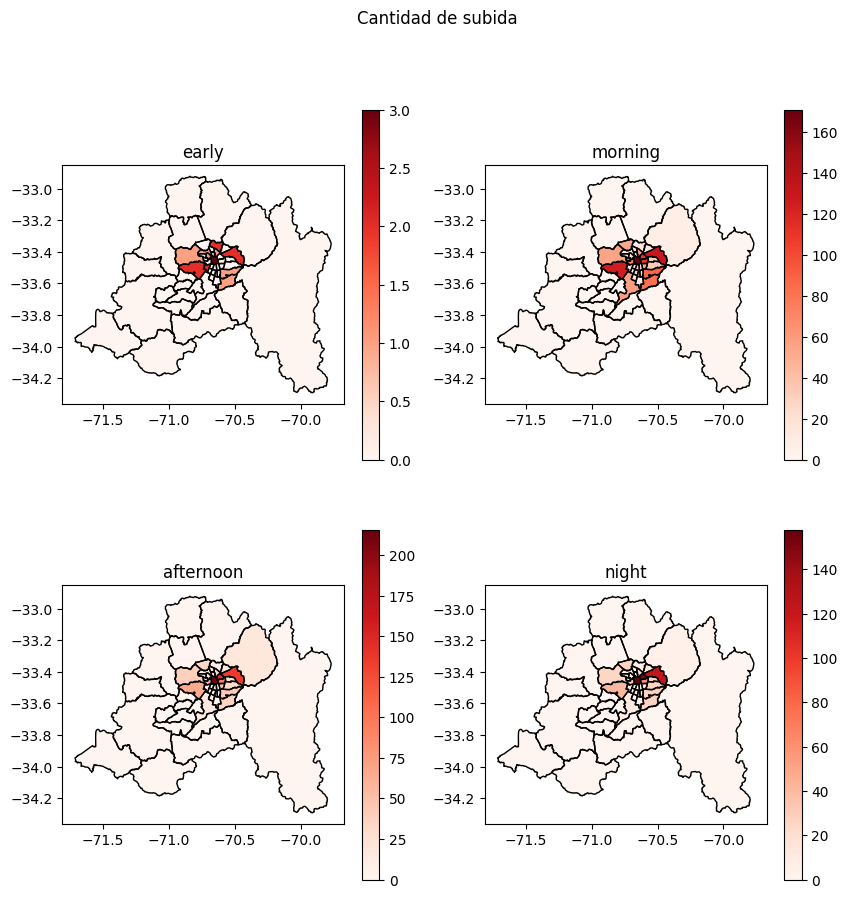

In [147]:
fig = plt.figure(figsize=(10,10))
fig.suptitle("Cantidad de subida")

for i, time in enumerate(["early", "morning", "afternoon", "night"], 1):
    ax = fig.add_subplot(220+i)
    shp_con_dato_subida.boundary.plot(ax=ax, color="black", linewidth=1)
    shp_con_dato_subida.plot(ax=ax, column=time, cmap='Reds', legend=True)
    ax.set_title(time)

## Veamos en que comunas se bajan más:

In [148]:
shp_con_dato_bajada = pd.merge(comunas_santiago, pv_bajada, how="outer", left_on="Comuna", right_index=True)
shp_con_dato_bajada.fillna(0.0, inplace=True)

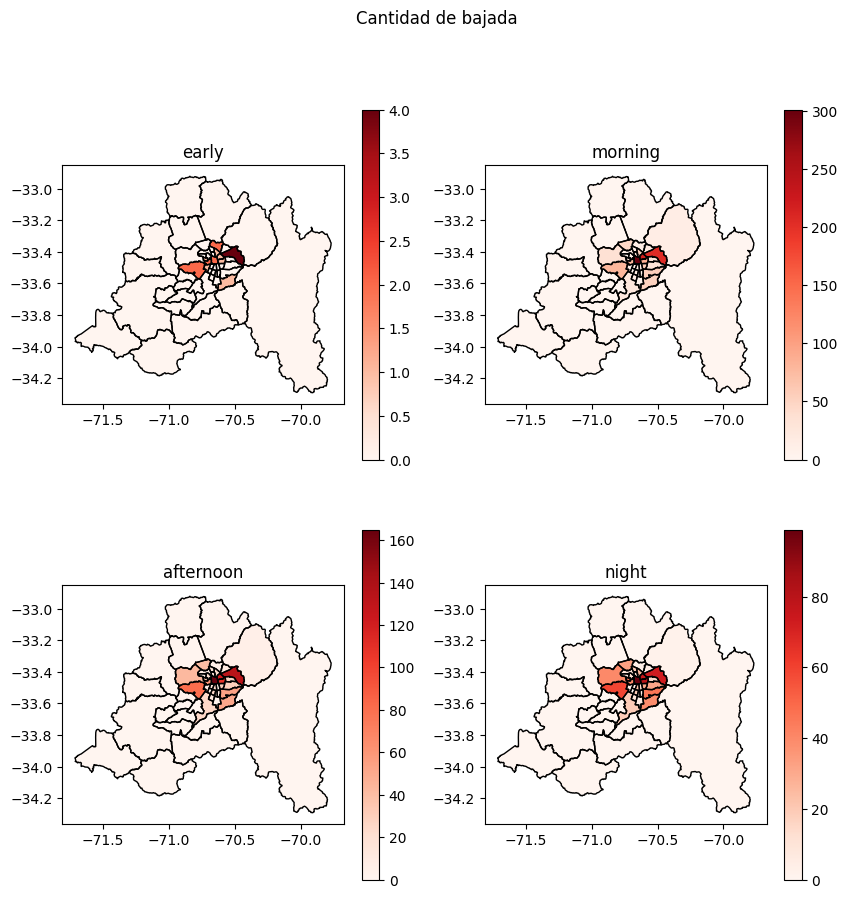

In [149]:
fig = plt.figure(figsize=(10,10))
fig.suptitle("Cantidad de bajada")

for i, time in enumerate(["early", "morning", "afternoon", "night"], 1):
    ax = fig.add_subplot(220+i)
    shp_con_dato_bajada.boundary.plot(ax=ax, color="black", linewidth=1)
    shp_con_dato_bajada.plot(ax=ax, column=time, cmap='Reds', legend=True)
    ax.set_title(time)

## Ahora veamos cuanto tiempo viaja la mayoria de pasajeros:

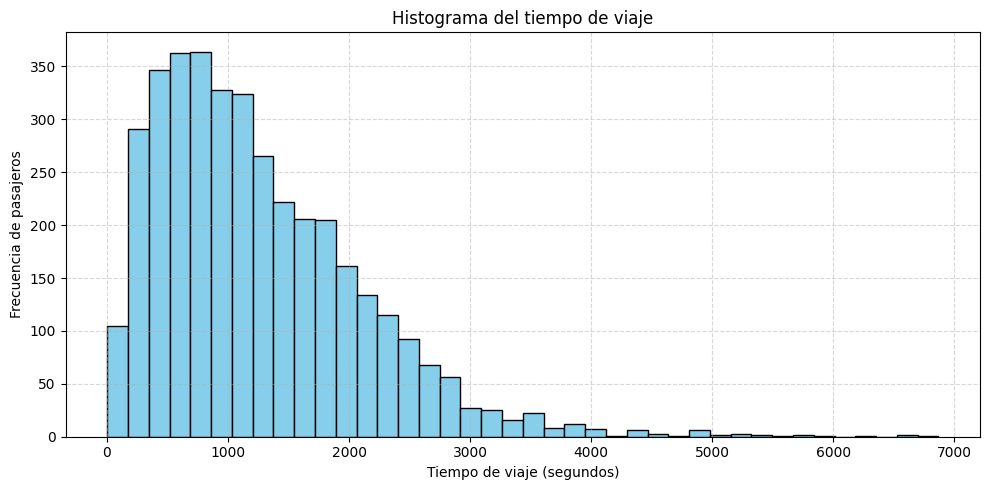

In [150]:


plt.figure(figsize=(10,5))
plt.hist(df_has_bajada['tiempo_etapa'].dropna(), bins=40, color='skyblue', edgecolor='black')
plt.title('Histograma del tiempo de viaje')
plt.xlabel('Tiempo de viaje (segundos)')
plt.ylabel('Frecuencia de pasajeros')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### _Al revisar el grafico podemos ver que la mayoria de datos se encuentran bajo los 1500 segundos! Es decir, los 25 minutos aproximadamente. Podemos ver que en esos viajes existe mayor cantidad de pasajeros_

## Tambien podemos comparar estos mismos tiempos y frecuencia entre cada transporte:

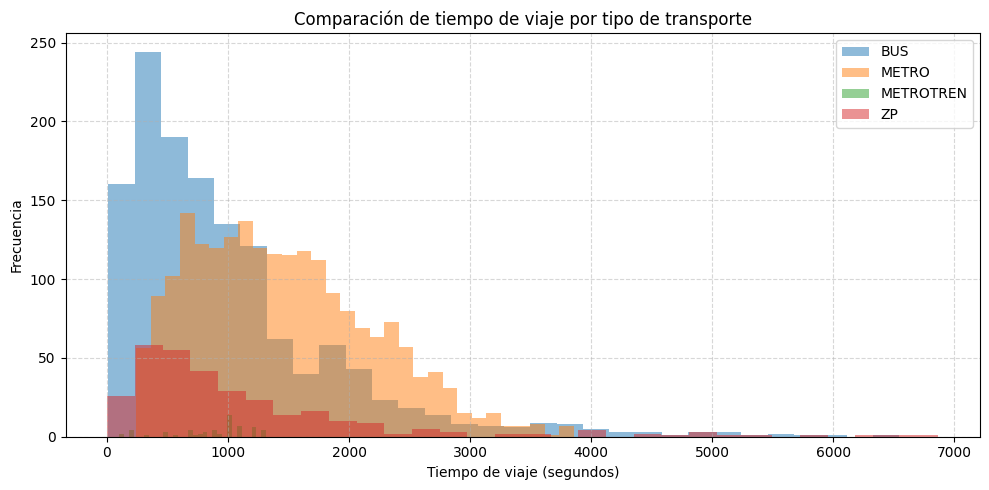

In [151]:
plt.figure(figsize=(10,5))
for tipo in df_has_bajada['tipo_transporte'].dropna().unique():
    subset = df_has_bajada[df_has_bajada['tipo_transporte'] == tipo]['tiempo_etapa'].dropna()
    plt.hist(subset, bins=30, alpha=0.5, label=tipo)

plt.title('Comparación de tiempo de viaje por tipo de transporte')
plt.xlabel('Tiempo de viaje (segundos)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



### _Podemos ver que el metro se utliza para transportes de mayor duracion. A la misma vez la mayoria de viajes en micro tienden a durar menos de 15 minutos (1000 segundos)_


## Tambien queremos ver mejor los horarios en que hay mas personas:

C:\Users\czz\AppData\Local\Temp\ipykernel_10920\1238033252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_has_bajada['hora'] = df_has_bajada['tiempo_subida'].dt.hour


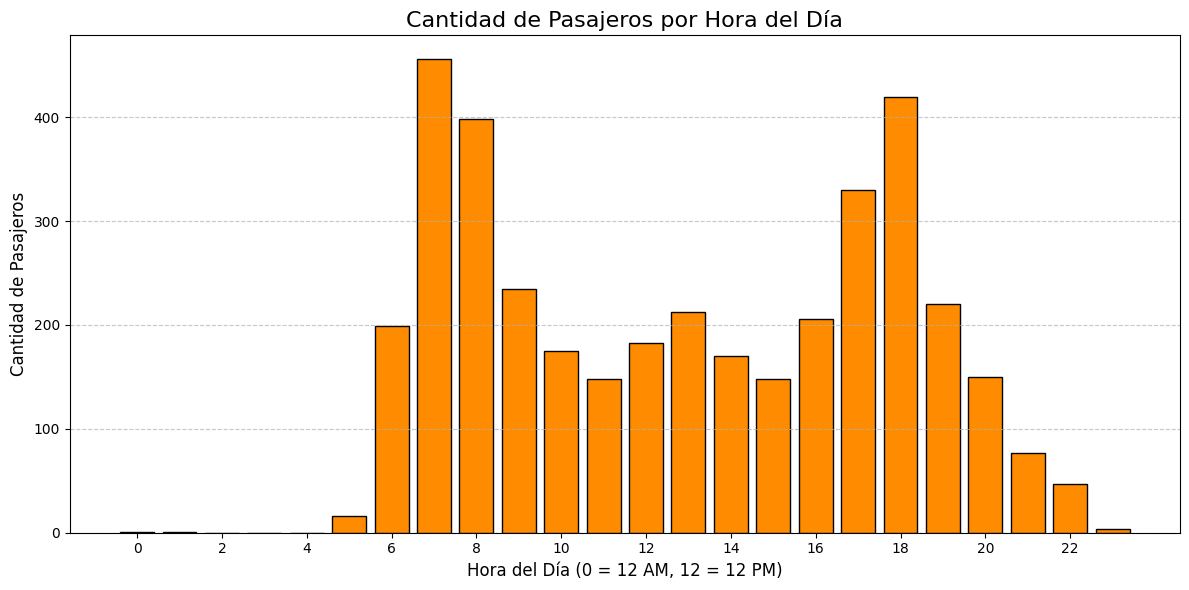

In [152]:
df_has_bajada['hora'] = df_has_bajada['tiempo_subida'].dt.hour

pasajeros_por_hora = df_has_bajada.groupby('hora').size().reset_index(name='cantidad_pasajeros')

# CODIGO SUGERIDO POR IA, PROMPT: "Como puedo asegurar que todas las 24 horas estén presentes"
# Esto garantiza que el gráfico no tenga saltos si no hubo viajes a una hora específica.
# Crea un índice de 0 a 23 y rellena las horas sin datos con 0.
pasajeros_por_hora = pasajeros_por_hora.set_index('hora').reindex(range(24), fill_value=0).reset_index()
# FIN CODIO IA

plt.figure(figsize=(12, 6))
plt.bar(
    pasajeros_por_hora['hora'], 
    pasajeros_por_hora['cantidad_pasajeros'], 
    color='darkorange',
    edgecolor='black'
)

plt.title('Cantidad de Pasajeros por Hora del Día', fontsize=16)
plt.xlabel('Hora del Día (0 = 12 AM, 12 = 12 PM)', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)

plt.xticks(range(0, 24, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### _Evidentemente podemos ver en las horas peak (6am-8am y 5pm-6pm) un aumento considerable de la candidad de pasajeros_

## Incluso podemos revisar en que horarios toman mas tiempo los viajes:

C:\Users\czz\AppData\Local\Temp\ipykernel_10920\60329942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_has_bajada['hora'] = df_has_bajada['hora'].astype('category')


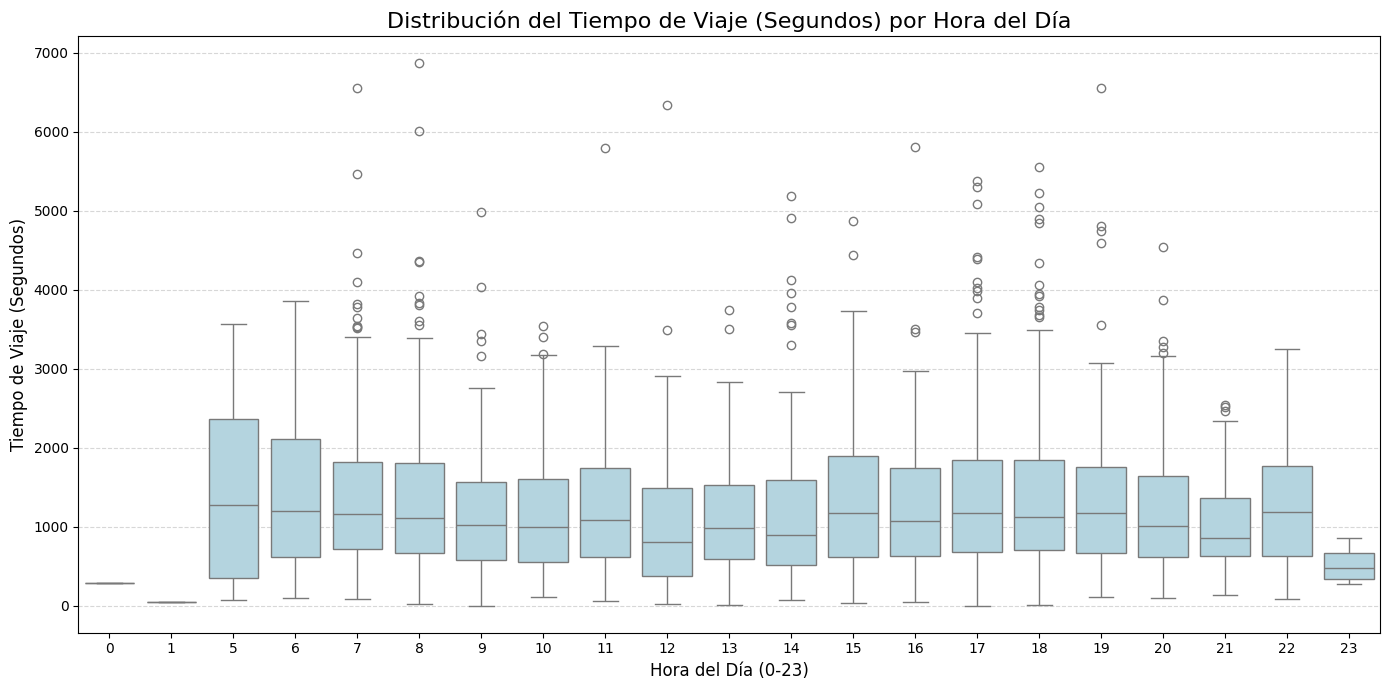

In [153]:
df_has_bajada['hora'] = df_has_bajada['hora'].astype('category')
plt.figure(figsize=(14, 7))

sns.boxplot(x='hora', y='tiempo_etapa', data=df_has_bajada, color='lightblue')

plt.title('Distribución del Tiempo de Viaje (Segundos) por Hora del Día', fontsize=16)
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Tiempo de Viaje (Segundos)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### _Al prestar atencio a este grafico podemos ver que, en las mismas horas peak, existe mayor cantidad de "outliers". En otras palabras, los valores se salen aun mas de rango (toman mas tiempo)_

## Ademas, podemos verificar de donde vienen la mayoria de datos de transporte:

C:\Users\czz\AppData\Local\Temp\ipykernel_10920\2113336938.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pasajeros_por_transporte = df_has_bajada.groupby('tipo_transporte').size().reset_index(name='cantidad_pasajeros')


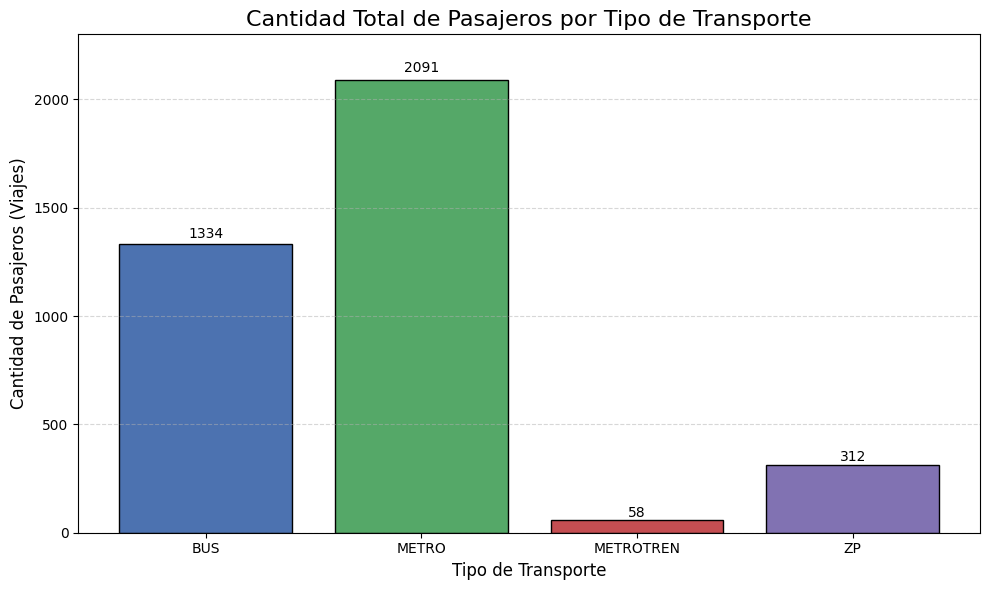

In [154]:
pasajeros_por_transporte = df_has_bajada.groupby('tipo_transporte').size().reset_index(name='cantidad_pasajeros')

plt.figure(figsize=(10, 6))

barras = plt.bar(
    pasajeros_por_transporte['tipo_transporte'], 
    pasajeros_por_transporte['cantidad_pasajeros'], 
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],  # Codigo de colores sugerido por IA, prompt: "Que colores puedo usar en grafico python? Como los anoto?"
    edgecolor='black'
)
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), 
             int(yval), ha='center', va='bottom', fontsize=10)

plt.title('Cantidad Total de Pasajeros por Tipo de Transporte', fontsize=16)
plt.xlabel('Tipo de Transporte', fontsize=12)
plt.ylabel('Cantidad de Pasajeros (Viajes)', fontsize=12)

# Quitar el límite superior del eje Y y hacer que el eje Y comience en 0 
plt.ylim(bottom=0, top=pasajeros_por_transporte['cantidad_pasajeros'].max() * 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### _Claramente podemos ver que la mayoria de nuestros datos provienen de transportes como metro o bus_